In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/data.yaml
/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/valid/labels/Screenshot-2023-11-01-024837_png_jpg.rf.88a97894cd867f8c8c8a1202145b6b97.txt
/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/valid/labels/Screenshot-2023-11-02-113440_png_jpg.rf.a9a939331109acfdac8b6a637ebc5dfb.txt
/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/valid/labels/image_from_china-2938-_jpg.rf.251ddac45d93df97c61ec4159102b994.txt
/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/valid/labels/IMG_2225_PNG_jpg.rf.468e0ce79fb5c2a00602785559570ce5.txt
/kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-data

In [2]:
!pip install -q ultralytics

# 2. Verify GPU availability
import ultralytics
from ultralytics import YOLO
ultralytics.checks()


Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.6/8062.4 GB disk)


In [3]:
import os
from pathlib import Path

# In Kaggle, datasets are automatically extracted to /kaggle/input/
input_dir = Path("/kaggle/input")
train_img_path = None
val_img_path = None

# Dynamically search for the 'train' and 'valid' image directories
for path in input_dir.rglob("*"):
    if path.is_dir() and path.name == "train":
        train_img_path = path.as_posix()
    elif path.is_dir() and path.name == "valid":
        val_img_path = path.as_posix()

if not train_img_path:
    print("Error: Could not find the 'train' folder. Make sure the dataset is added to your Kaggle notebook.")
else:
    # If the folders contain 'images' subfolders, append it
    if os.path.exists(os.path.join(train_img_path, "images")):
        train_img_path = os.path.join(train_img_path, "images")
        val_img_path = os.path.join(val_img_path, "images")

    # Create the data.yaml file in the writable working directory
    yaml_content = f"""
train: {train_img_path}
val: {val_img_path}

nc: 5
names: ['helmet', 'no_helmet', 'no_vest', 'person', 'vest']
"""

    yaml_file_path = "/kaggle/working/ppe_data.yaml"
    with open(yaml_file_path, "w") as f:
        f.write(yaml_content.strip())

    print(f"Configuration written to {yaml_file_path}:\n")
    print(yaml_content)

Configuration written to /kaggle/working/ppe_data.yaml:


train: /kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/train/images
val: /kaggle/input/datasets/ndomalau/personal-protective-equipment-ppe-dataset/Personal-Protective-Equipment (PPE) Dataset/valid/images

nc: 5
names: ['helmet', 'no_helmet', 'no_vest', 'person', 'vest']



In [4]:
from ultralytics import YOLO

# 1. Initialize YOLO11 small
model = YOLO("yolo11s.pt")

# 2. Execute Training
print("Starting YOLO11 training on 5-class PPE dataset with augmentations...")
train_results = model.train(
    data="/kaggle/working/ppe_data.yaml",
    epochs=50,                   
    imgsz=640,
    batch=16,
    
    # --- Data Augmentation Parameters ---
    hsv_h=0.015,       # Adjusts hue to generalize across color variations
    hsv_s=0.7,         # Adjusts saturation to simulate different environmental conditions
    hsv_v=0.4,         # Adjusts brightness to handle harsh outdoor exposure levels
    degrees=10.0,      # Random rotation up to 10 degrees
    translate=0.1,     # Shifts the image horizontally and vertically
    scale=0.5,         # Randomly scales to simulate objects at different distances
    shear=2.0,         # Adds perspective-like distortions (mimics camera angles)
    fliplr=0.5,        # 50% probability to flip images horizontally
    mosaic=1.0,        # Combines 4 images into one, heavily improving small-object detection
    erasing=0.4,       # Randomly erases patches to train the model to handle occlusion
    
    project="/kaggle/working/Graduation_Project",
    name="YOLO11_PPE_Augmented",
    save=True
)

print("\nTraining Complete! Check '/kaggle/working/Graduation_Project/YOLO11_PPE_Augmented/' for weights and plots.")

Starting YOLO11 training on 5-class PPE dataset with augmentations...
Ultralytics 8.4.152 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/ppe_data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      5.16G      1.518        1.3      1.507        169        640: 100% ━━━━━━━━━━━━ 203/203 4.6it/s 44.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.7it/s 3.5s0.3s
                   all        406       3095      0.718      0.654      0.716      0.356

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      5.16G      1.543      1.316      1.526        216        640: 100% ━━━━━━━━━━━━ 203/203 4.6it/s 44.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.8it/s 3.5s0.3s
                   all        406       3095      0.769      0.685      0.742      0.361

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      5.16G       1.51      1.271      1.509        252        640: 100% ━━━━━━━━━━━━ 203/203 4.5it/s 45.3s0.2ss
                 Class     Ima

--- Final Validation Metrics ---
Final mAP@0.5:     0.920
Final mAP@0.5:0.95:0.598

--- Displaying Confusion Matrix ---


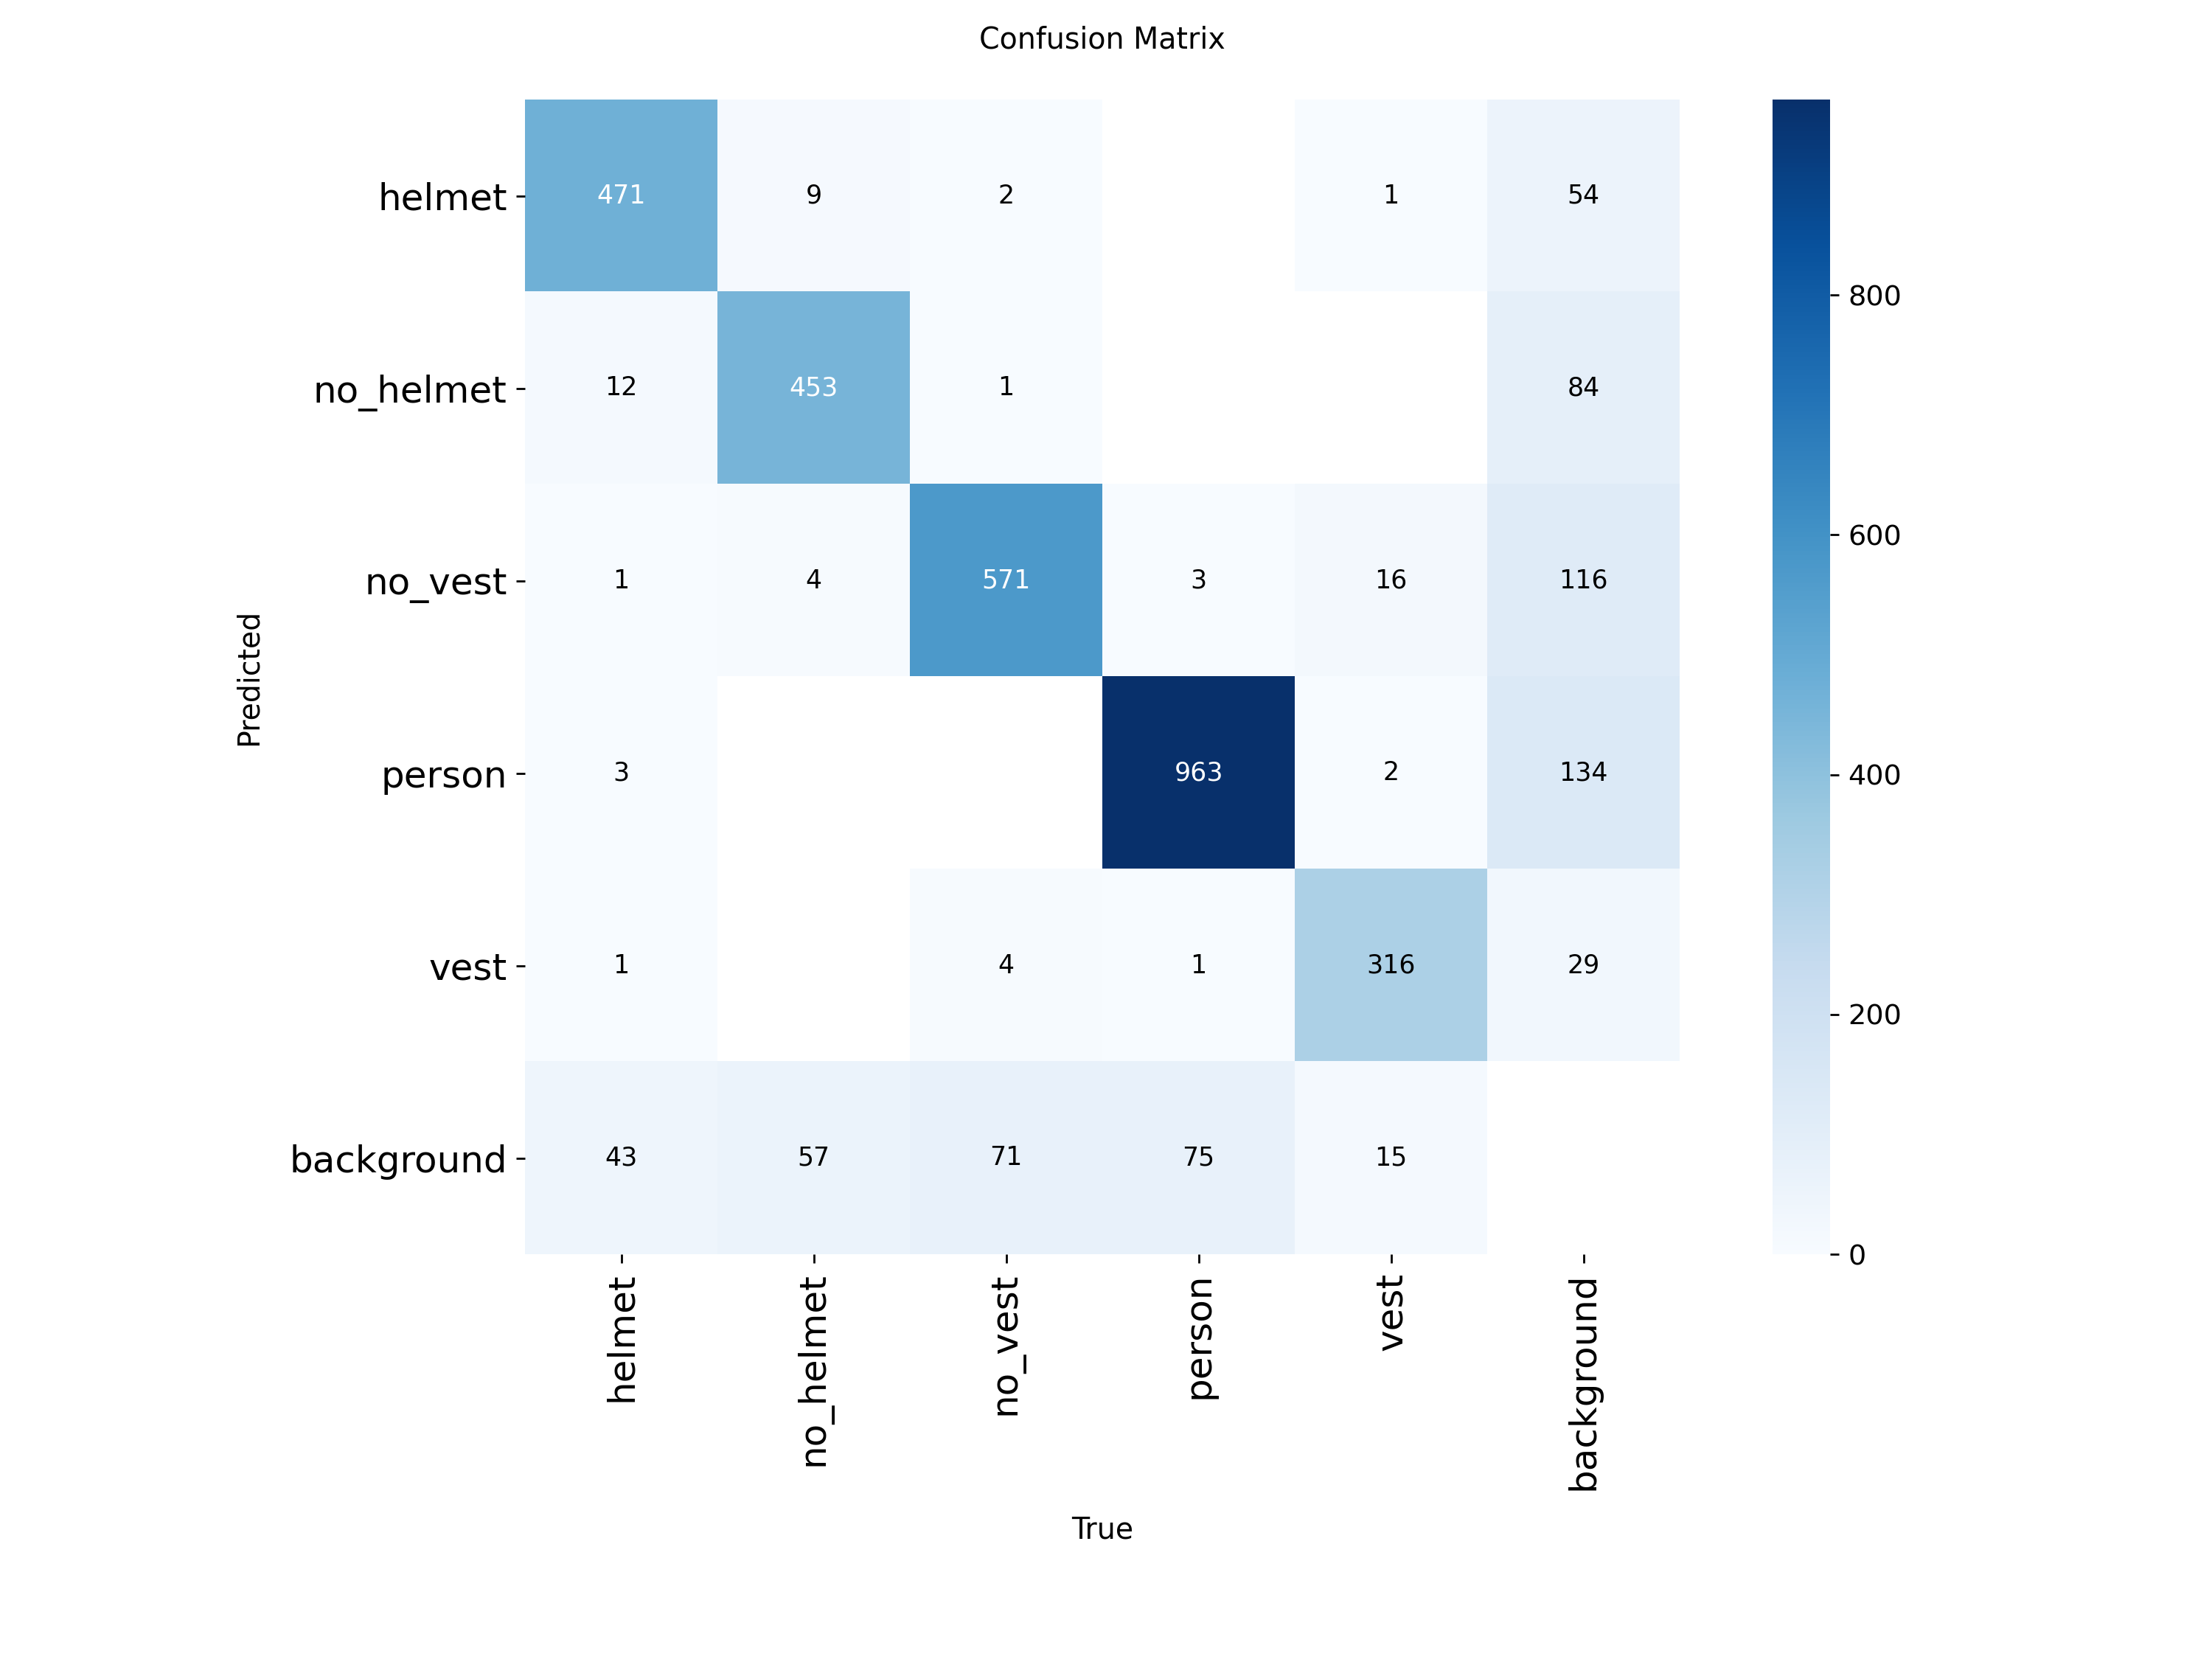


--- Displaying Learning Curves (results.png) ---


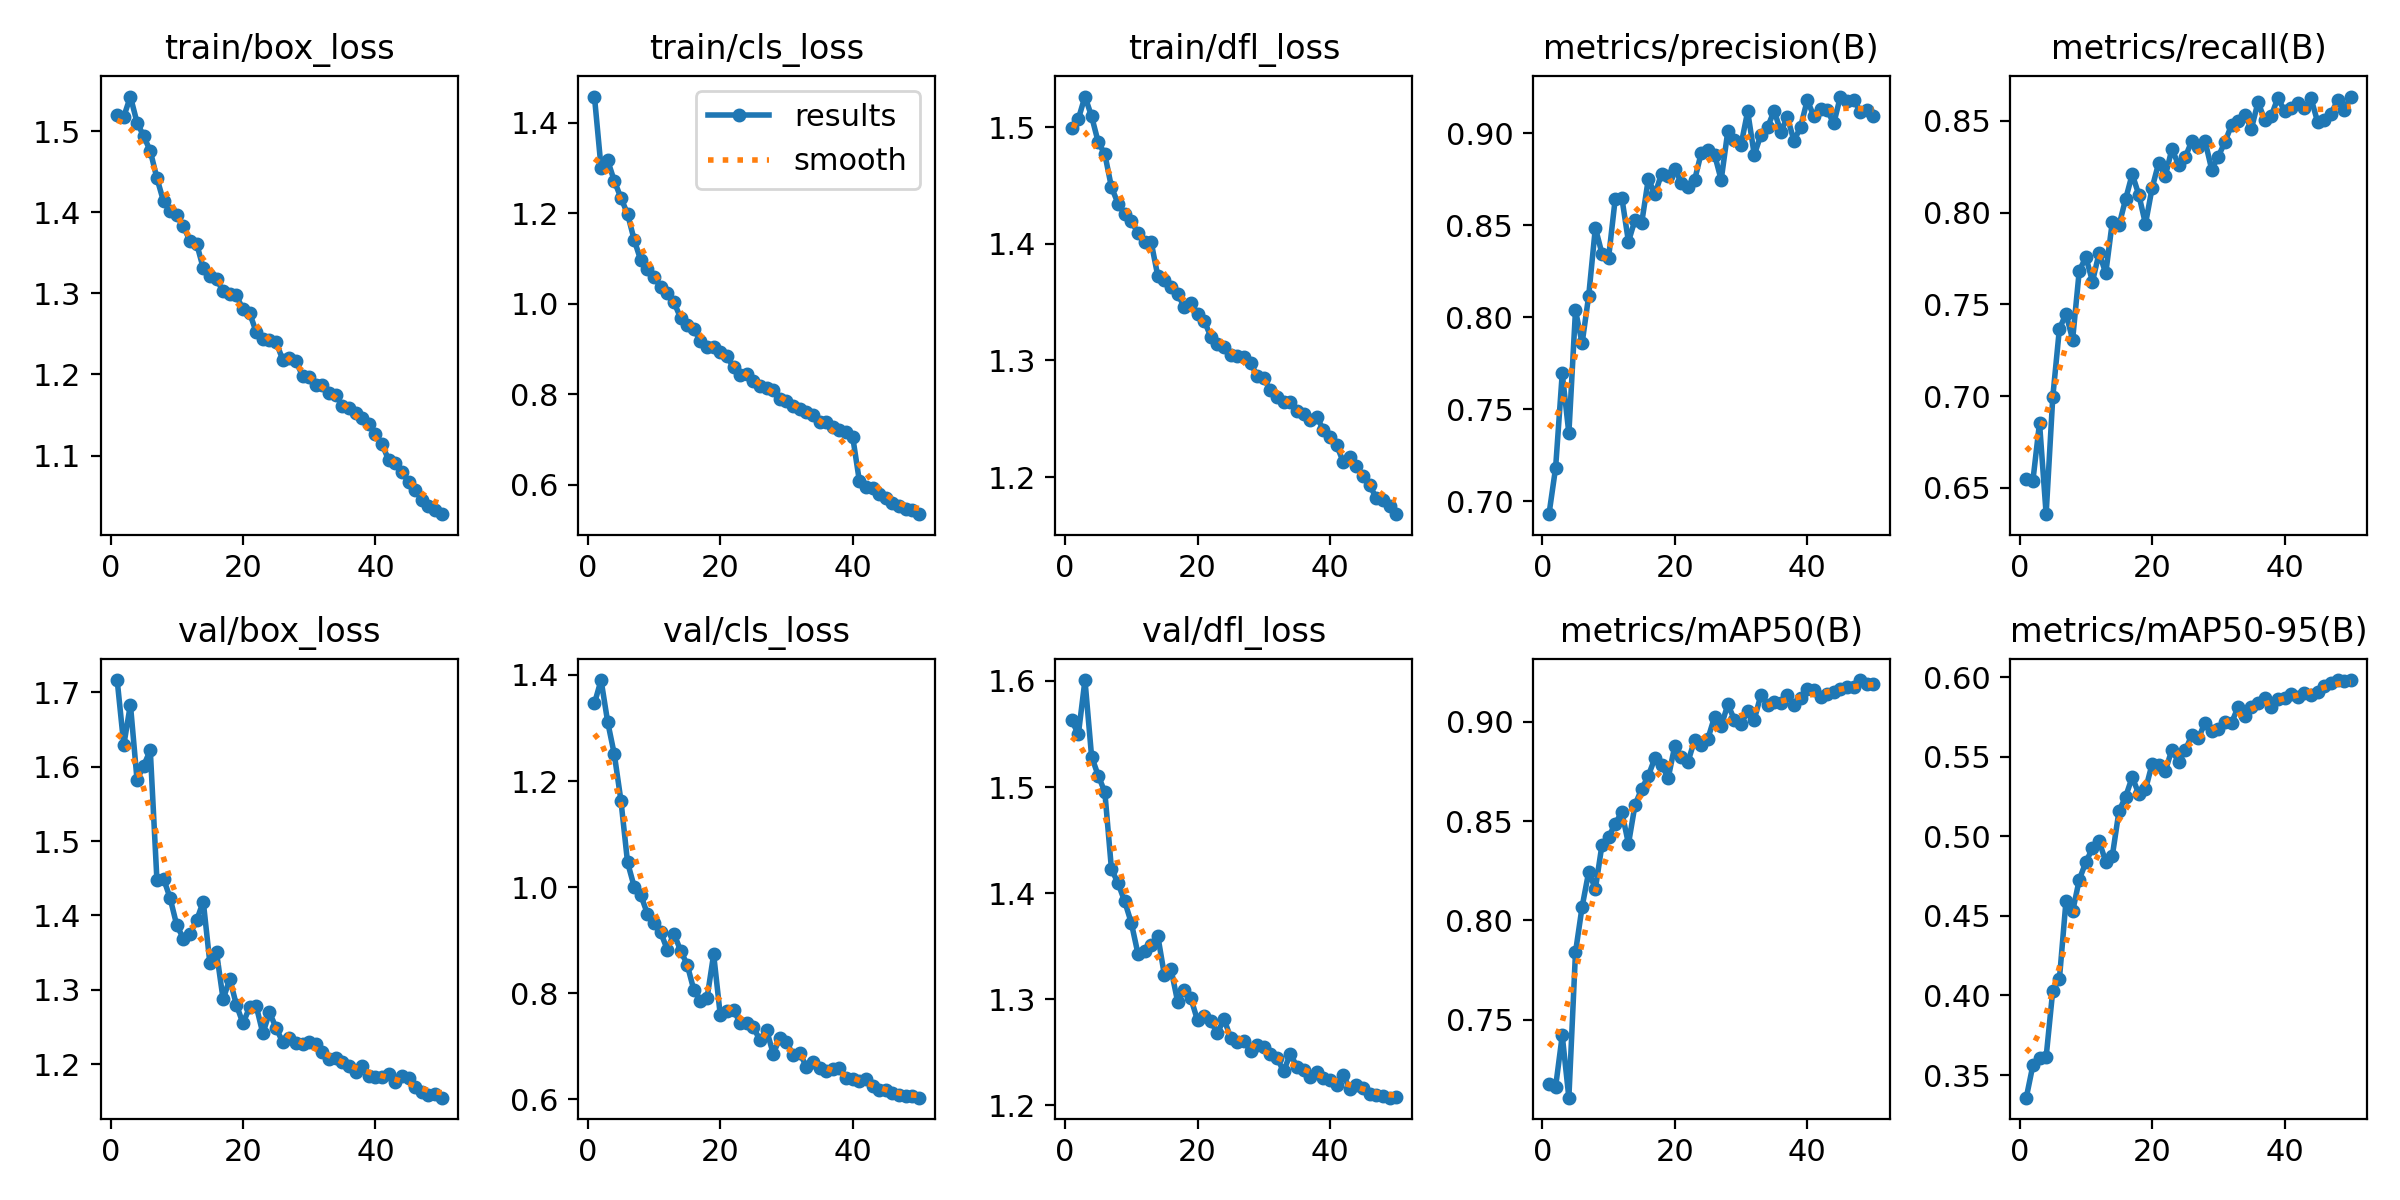


--- Displaying Sample Validation Predictions ---


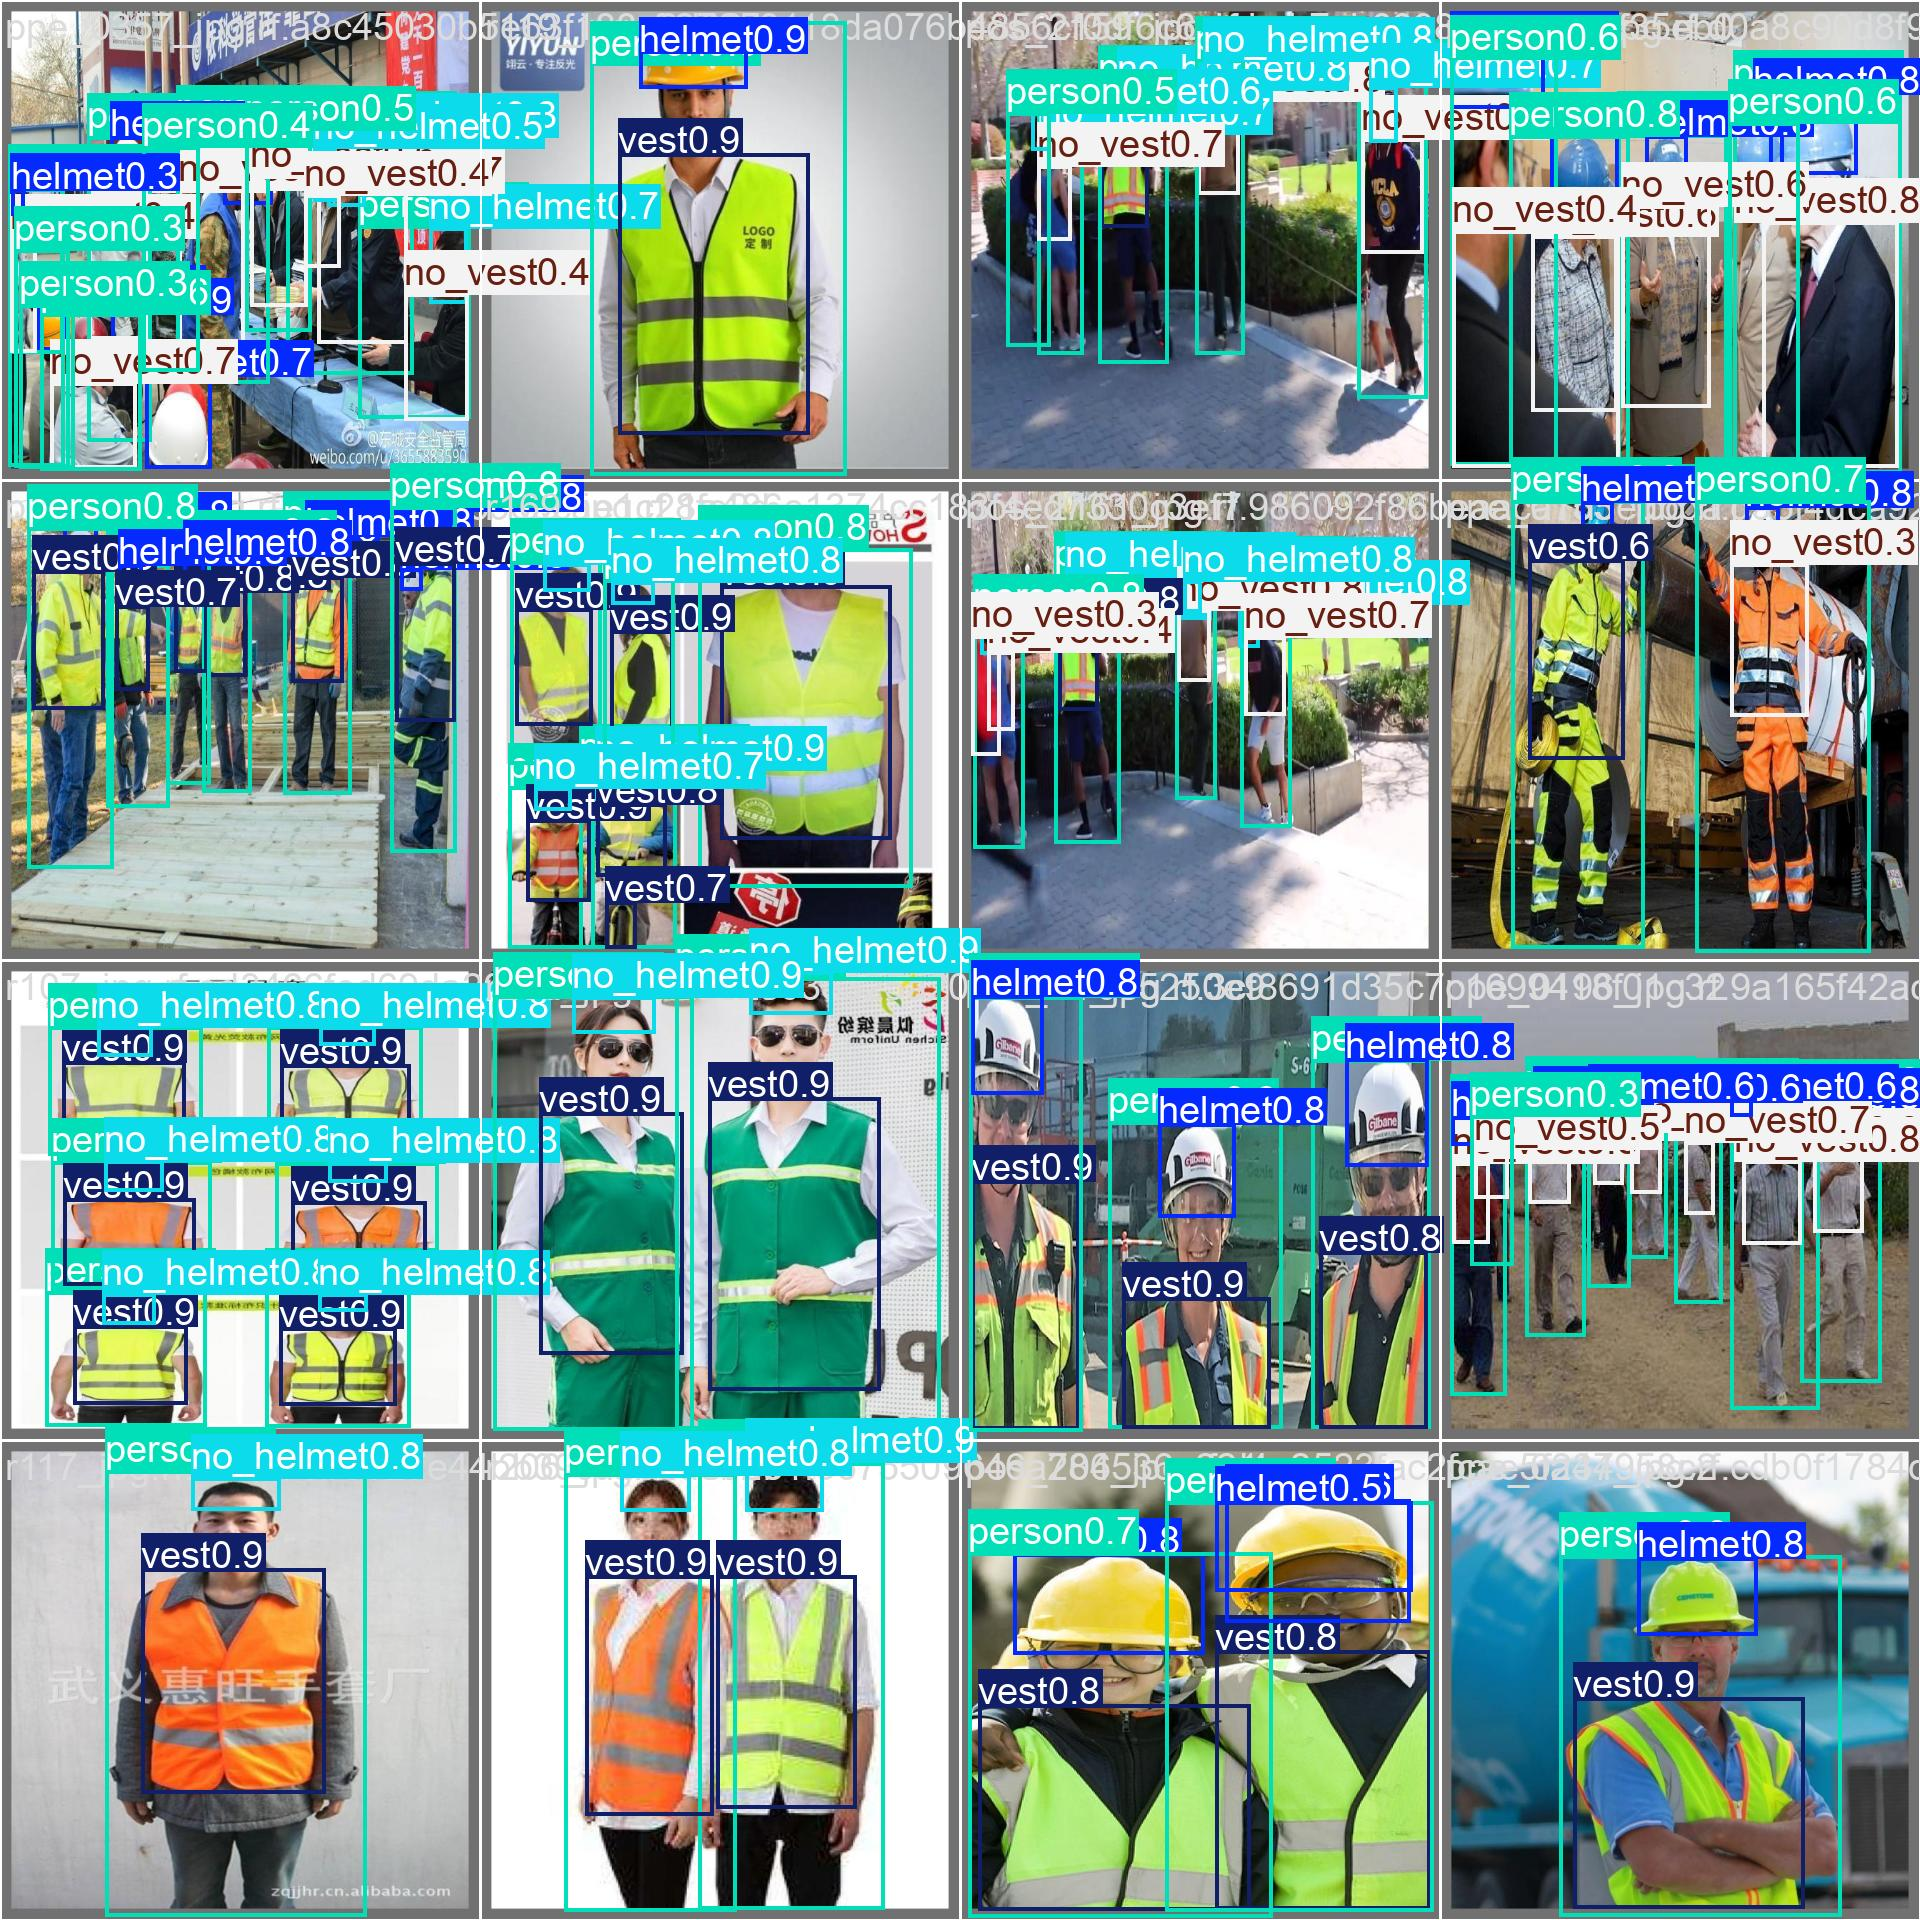

In [5]:
from IPython.display import Image, display

# Print summary metrics from validation
print("--- Final Validation Metrics ---")
print(f"Final mAP@0.5:     {train_results.box.map50:.3f}")
print(f"Final mAP@0.5:0.95:{train_results.box.map:.3f}")

# Display Confusion Matrix
print("\n--- Displaying Confusion Matrix ---")
display(Image(filename="/kaggle/working/Graduation_Project/YOLO11_PPE_Augmented/confusion_matrix.png", width=700))

# Display Loss and mAP curves across epochs
print("\n--- Displaying Learning Curves (results.png) ---")
display(Image(filename="/kaggle/working/Graduation_Project/YOLO11_PPE_Augmented/results.png", width=900))

# Display Batch Predictions
print("\n--- Displaying Sample Validation Predictions ---")
display(Image(filename="/kaggle/working/Graduation_Project/YOLO11_PPE_Augmented/val_batch0_pred.jpg", width=900))

Running custom inference & safety compliance logic...

Found https://www.shutterstock.com/image-photo/engineer-wearing-hard-hat-safety-600w-2686719375.jpg locally at engineer-wearing-hard-hat-safety-600w-2686719375.jpg
image 1/1 /kaggle/working/engineer-wearing-hard-hat-safety-600w-2686719375.jpg: 448x640 1 helmet, 1 person, 1 vest, 13.7ms
Speed: 2.0ms preprocess, 13.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


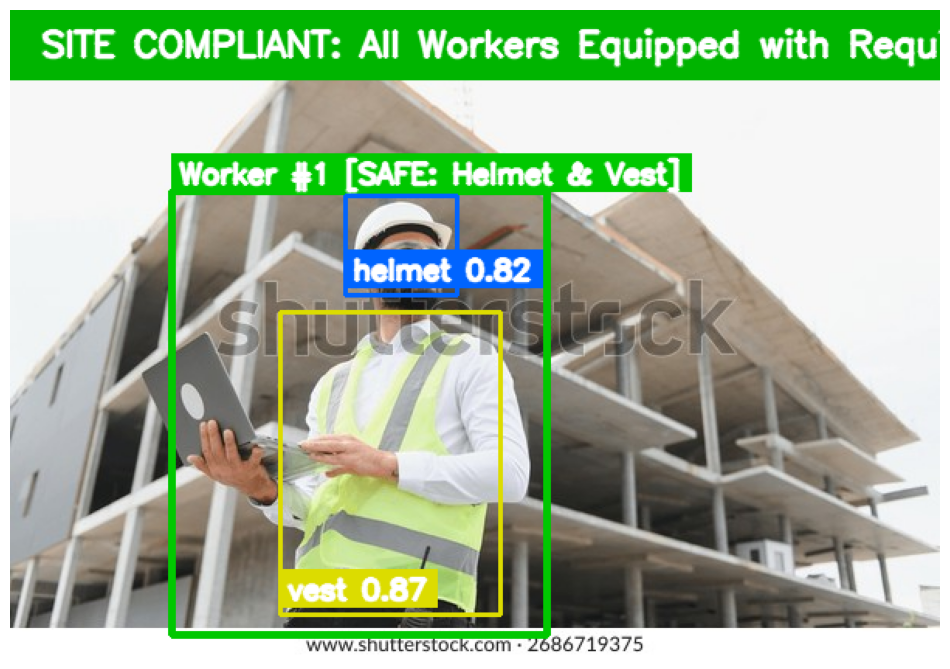


--- Site Inspection Summary ---
Total Workers Inspected: 1
Safe & Compliant:        1
Warnings (Partial PPE):  0
Critical Violations:     0


In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Target Image URL (or path to local image)
test_image_url = "https://www.shutterstock.com/image-photo/engineer-wearing-hard-hat-safety-600w-2686719375.jpg"

# 2. Run Inference without saving the default cluttered plot
print("Running custom inference & safety compliance logic...")
predict_results = model.predict(
    source=test_image_url,
    conf=0.35, # Global threshold
    save=False
)

result = predict_results[0]
orig_img = result.orig_img.copy()
img_h, img_w = orig_img.shape[:2]

# Map class IDs to names: ['helmet', 'no_helmet', 'no_vest', 'person', 'vest']
names = model.names

# Parse all detections
persons = []
helmets = []
vests = []

for box in result.boxes:
    xyxy = box.xyxy[0].cpu().numpy().astype(int) # [x1, y1, x2, y2]
    cls_id = int(box.cls[0].cpu().numpy())
    conf = float(box.conf[0].cpu().numpy())
    label = names[cls_id]

    if label.lower() == 'person':
        persons.append({'box': xyxy, 'conf': conf})
    elif label.lower() in ['helmet', 'no_helmet']:
        helmets.append({'box': xyxy, 'conf': conf, 'label': label.lower()})
    elif label.lower() in ['vest', 'no_vest']:
        vests.append({'box': xyxy, 'conf': conf, 'label': label.lower()})

# Helper function to check if a gear center is inside the person's box
def is_inside(gear_box, person_box):
    gx_center = (gear_box[0] + gear_box[2]) / 2
    gy_center = (gear_box[1] + gear_box[3]) / 2
    px1, py1, px2, py2 = person_box
    return (px1 <= gx_center <= px2) and (py1 <= gy_center <= py2)

# Helper function to draw clean, non-overlapping label banners
def draw_label(img, text, x, y, bg_color, text_color=(255, 255, 255)):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    thickness = 2
    (w, h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
    
    # Avoid drawing off the top edge of the image
    y_bg1 = max(0, y - h - 10)
    y_bg2 = max(h + 10, y)
    
    cv2.rectangle(img, (x, y_bg1), (x + w + 10, y_bg2), bg_color, -1)
    cv2.putText(img, text, (x + 5, y_bg2 - 5), font, font_scale, text_color, thickness, cv2.LINE_AA)

critical_violations = 0
warnings_count = 0
safe_count = 0

# 3. Evaluate each Person with the Compliance Logic
for idx, p in enumerate(persons):
    p_box = p['box']
    px1, py1, px2, py2 = p_box

    # Check which gear belongs to this person
    has_helmet = any(is_inside(h['box'], p_box) and h['label'] == 'helmet' for h in helmets)
    has_vest = any(is_inside(v['box'], p_box) and v['label'] == 'vest' for v in vests)

    # 4. IF-ELSE Compliance Decision Tree
    if has_helmet and has_vest:
        # FULL COMPLIANCE -> GREEN
        safe_count += 1
        box_color = (0, 200, 0) # Green (BGR)
        status_text = f"Worker #{idx+1} [SAFE: Helmet & Vest]"
        cv2.rectangle(orig_img, (px1, py1), (px2, py2), box_color, 3)
        draw_label(orig_img, status_text, px1, py1, box_color)

    elif has_helmet and not has_vest:
        # PARTIAL WARNING -> ORANGE
        warnings_count += 1
        box_color = (0, 140, 255) # Orange (BGR)
        status_text = f"Worker #{idx+1} [WARNING: Vest Missing]"
        cv2.rectangle(orig_img, (px1, py1), (px2, py2), box_color, 3)
        draw_label(orig_img, status_text, px1, py1, box_color)

    elif not has_helmet and has_vest:
        # PARTIAL WARNING -> ORANGE
        warnings_count += 1
        box_color = (0, 140, 255) # Orange (BGR)
        status_text = f"Worker #{idx+1} [WARNING: Helmet Missing]"
        cv2.rectangle(orig_img, (px1, py1), (px2, py2), box_color, 3)
        draw_label(orig_img, status_text, px1, py1, box_color)

    else:
        # ZERO GEAR DETECTED -> CRITICAL VIOLATION -> RED
        critical_violations += 1
        box_color = (0, 0, 255) # Red (BGR)
        status_text = f"Worker #{idx+1} [VIOLATION: NONE]"
        cv2.rectangle(orig_img, (px1, py1), (px2, py2), box_color, 4)
        draw_label(orig_img, status_text, px1, py1, box_color)

# 5. Draw individual Gear Bounding Boxes with custom offset labels
for h in helmets:
    hx1, hy1, hx2, hy2 = h['box']
    color = (255, 100, 0) if h['label'] == 'helmet' else (0, 0, 255)
    cv2.rectangle(orig_img, (hx1, hy1), (hx2, hy2), color, 2)
    # Offset label inside the box boundary to prevent collision with person banner
    draw_label(orig_img, f"{h['label']} {h['conf']:.2f}", hx1, hy2 - 5, color)

for v in vests:
    vx1, vy1, vx2, vy2 = v['box']
    color = (0, 220, 220) if v['label'] == 'vest' else (0, 0, 255)
    cv2.rectangle(orig_img, (vx1, vy1), (vx2, vy2), color, 2)
    draw_label(orig_img, f"{v['label']} {v['conf']:.2f}", vx1, vy2 - 5, color)

# 6. Global Top Banner Notification
if critical_violations > 0:
    banner_bg = (0, 0, 255) # Red
    banner_text = "CRITICAL ALERT: Worker must wear Helmet and Vest!"
elif warnings_count > 0:
    banner_bg = (0, 140, 255) # Orange
    banner_text = "SAFETY WARNING: Incomplete PPE Detected on Site."
else:
    banner_bg = (0, 180, 0) # Green
    banner_text = "SITE COMPLIANT: All Workers Equipped with Required PPE."

# Draw header overlay across top
cv2.rectangle(orig_img, (0, 0), (img_w, 45), banner_bg, -1)
cv2.putText(orig_img, banner_text, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)

# 7. Render Result
img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# Print Audit Summary
print("\n--- Site Inspection Summary ---")
print(f"Total Workers Inspected: {len(persons)}")
print(f"Safe & Compliant:        {safe_count}")
print(f"Warnings (Partial PPE):  {warnings_count}")
print(f"Critical Violations:     {critical_violations}")


image 1/1 /kaggle/working/stock-photo-senior-architect-and-group-of-workers-analyzing-building-plans-at-construction-site-2760344355.jpg: 480x640 2 helmets, 2 no_helmets, 4 persons, 4 vests, 63.0ms
Speed: 3.0ms preprocess, 63.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/Graduation_Project/Test_Inference


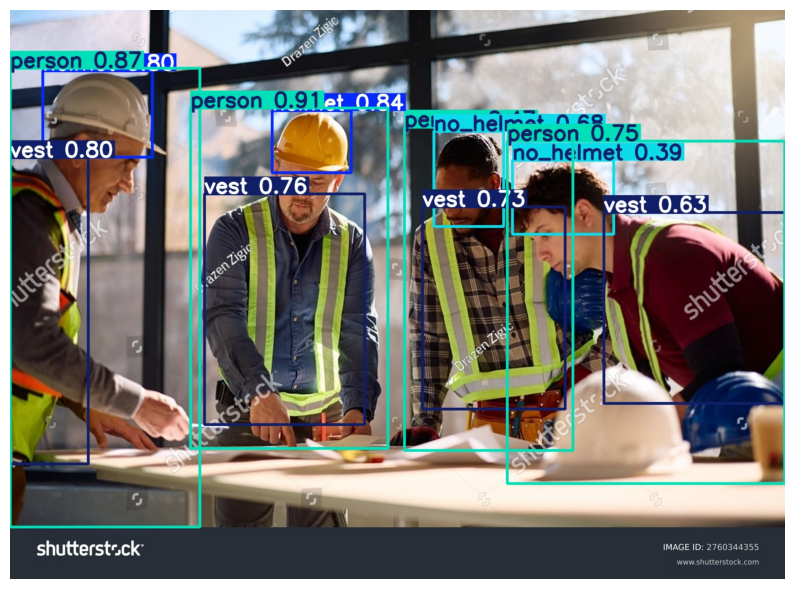

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

# 1. Target Image URL
test_image_url = "https://www.shutterstock.com/shutterstock/photos/2760344355/display_1500/stock-photo-senior-architect-and-group-of-workers-analyzing-building-plans-at-construction-site-2760344355.jpg"

# 2. Run Inference with custom weights
predict_results = model.predict(
    source=test_image_url,
    save=True,
    project="/kaggle/working/Graduation_Project",
    name="Test_Inference"
)

# 3. Display the saved detection directly from Ultralytics result object
predicted_img_path = os.path.join(predict_results[0].save_dir, os.path.basename(test_image_url))

if os.path.exists(predicted_img_path):
    img = cv2.imread(predicted_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    # Alternative fallback if path resolution fails
    annotated_frame = predict_results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.show()


image 1/1 /kaggle/working/happy-african-american-entrepreneur-using-600w-2756623021.jpg: 640x416 1 helmet, 1 no_vest, 1 person, 55.3ms
Speed: 1.8ms preprocess, 55.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 416)
Results saved to /kaggle/working/Graduation_Project/Test_Inference


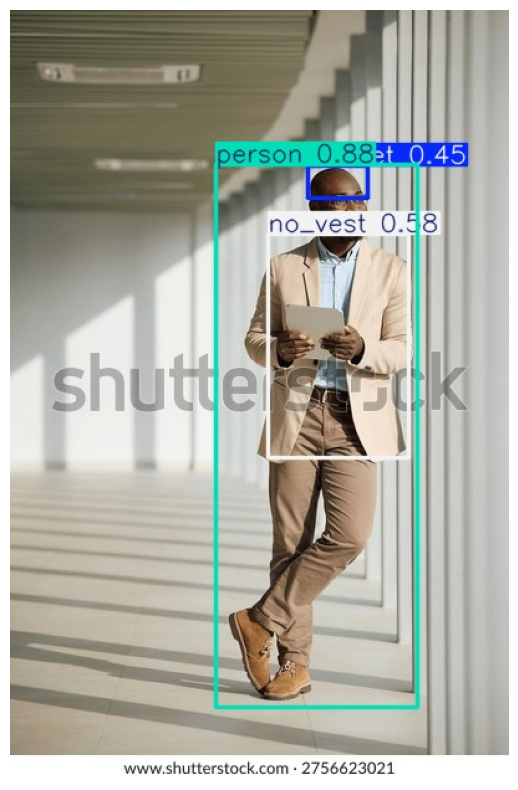

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# 1. Target Image URL
test_image_url = "https://www.shutterstock.com/image-photo/happy-african-american-entrepreneur-using-600w-2756623021.jpg"

# 2. Run Inference with custom weights
predict_results = model.predict(
    source=test_image_url,
    save=True,
    project="/kaggle/working/Graduation_Project",
    name="Test_Inference"
)

# 3. Display the saved detection directly from Ultralytics result object
predicted_img_path = os.path.join(predict_results[0].save_dir, os.path.basename(test_image_url))

if os.path.exists(predicted_img_path):
    img = cv2.imread(predicted_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    # Alternative fallback if path resolution fails
    annotated_frame = predict_results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.show()